In [1]:
# Evaluaation matrix in  classifiction

# Model Evaluation

accuracy=TP+TN/TP+TN+FP+FN

precision=TP/TP+FP

Recall=TP/TP+FN

In [5]:
# f1 score= 2*precision*recall / precision+recall 

error rate = FP+FN/Total

<!-- roc cureve=
roc curve is a graph between :
TPR(True positive Rate/Recall)
FPR(false postive rate ) -->

In [7]:
# roc curve=
# Roc curve is  graph between :
# TPR(True POstive rate)
# FPR(False postive rate )

In [9]:
# 3*3 confusion matrix assignment 

# KNN mens

In [10]:
# import all required libraries

import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import KNeighborsRegressor # For regression task
from sklearn.preprocessing import StandardScaler 
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix,classification_report,recall_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [11]:
# Reading the data
data = pd.read_csv("C:/Users/Dell/OneDrive/Desktop/diabetes1.csv") 
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [12]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [13]:
# Cheking for null values
data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [16]:
data.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

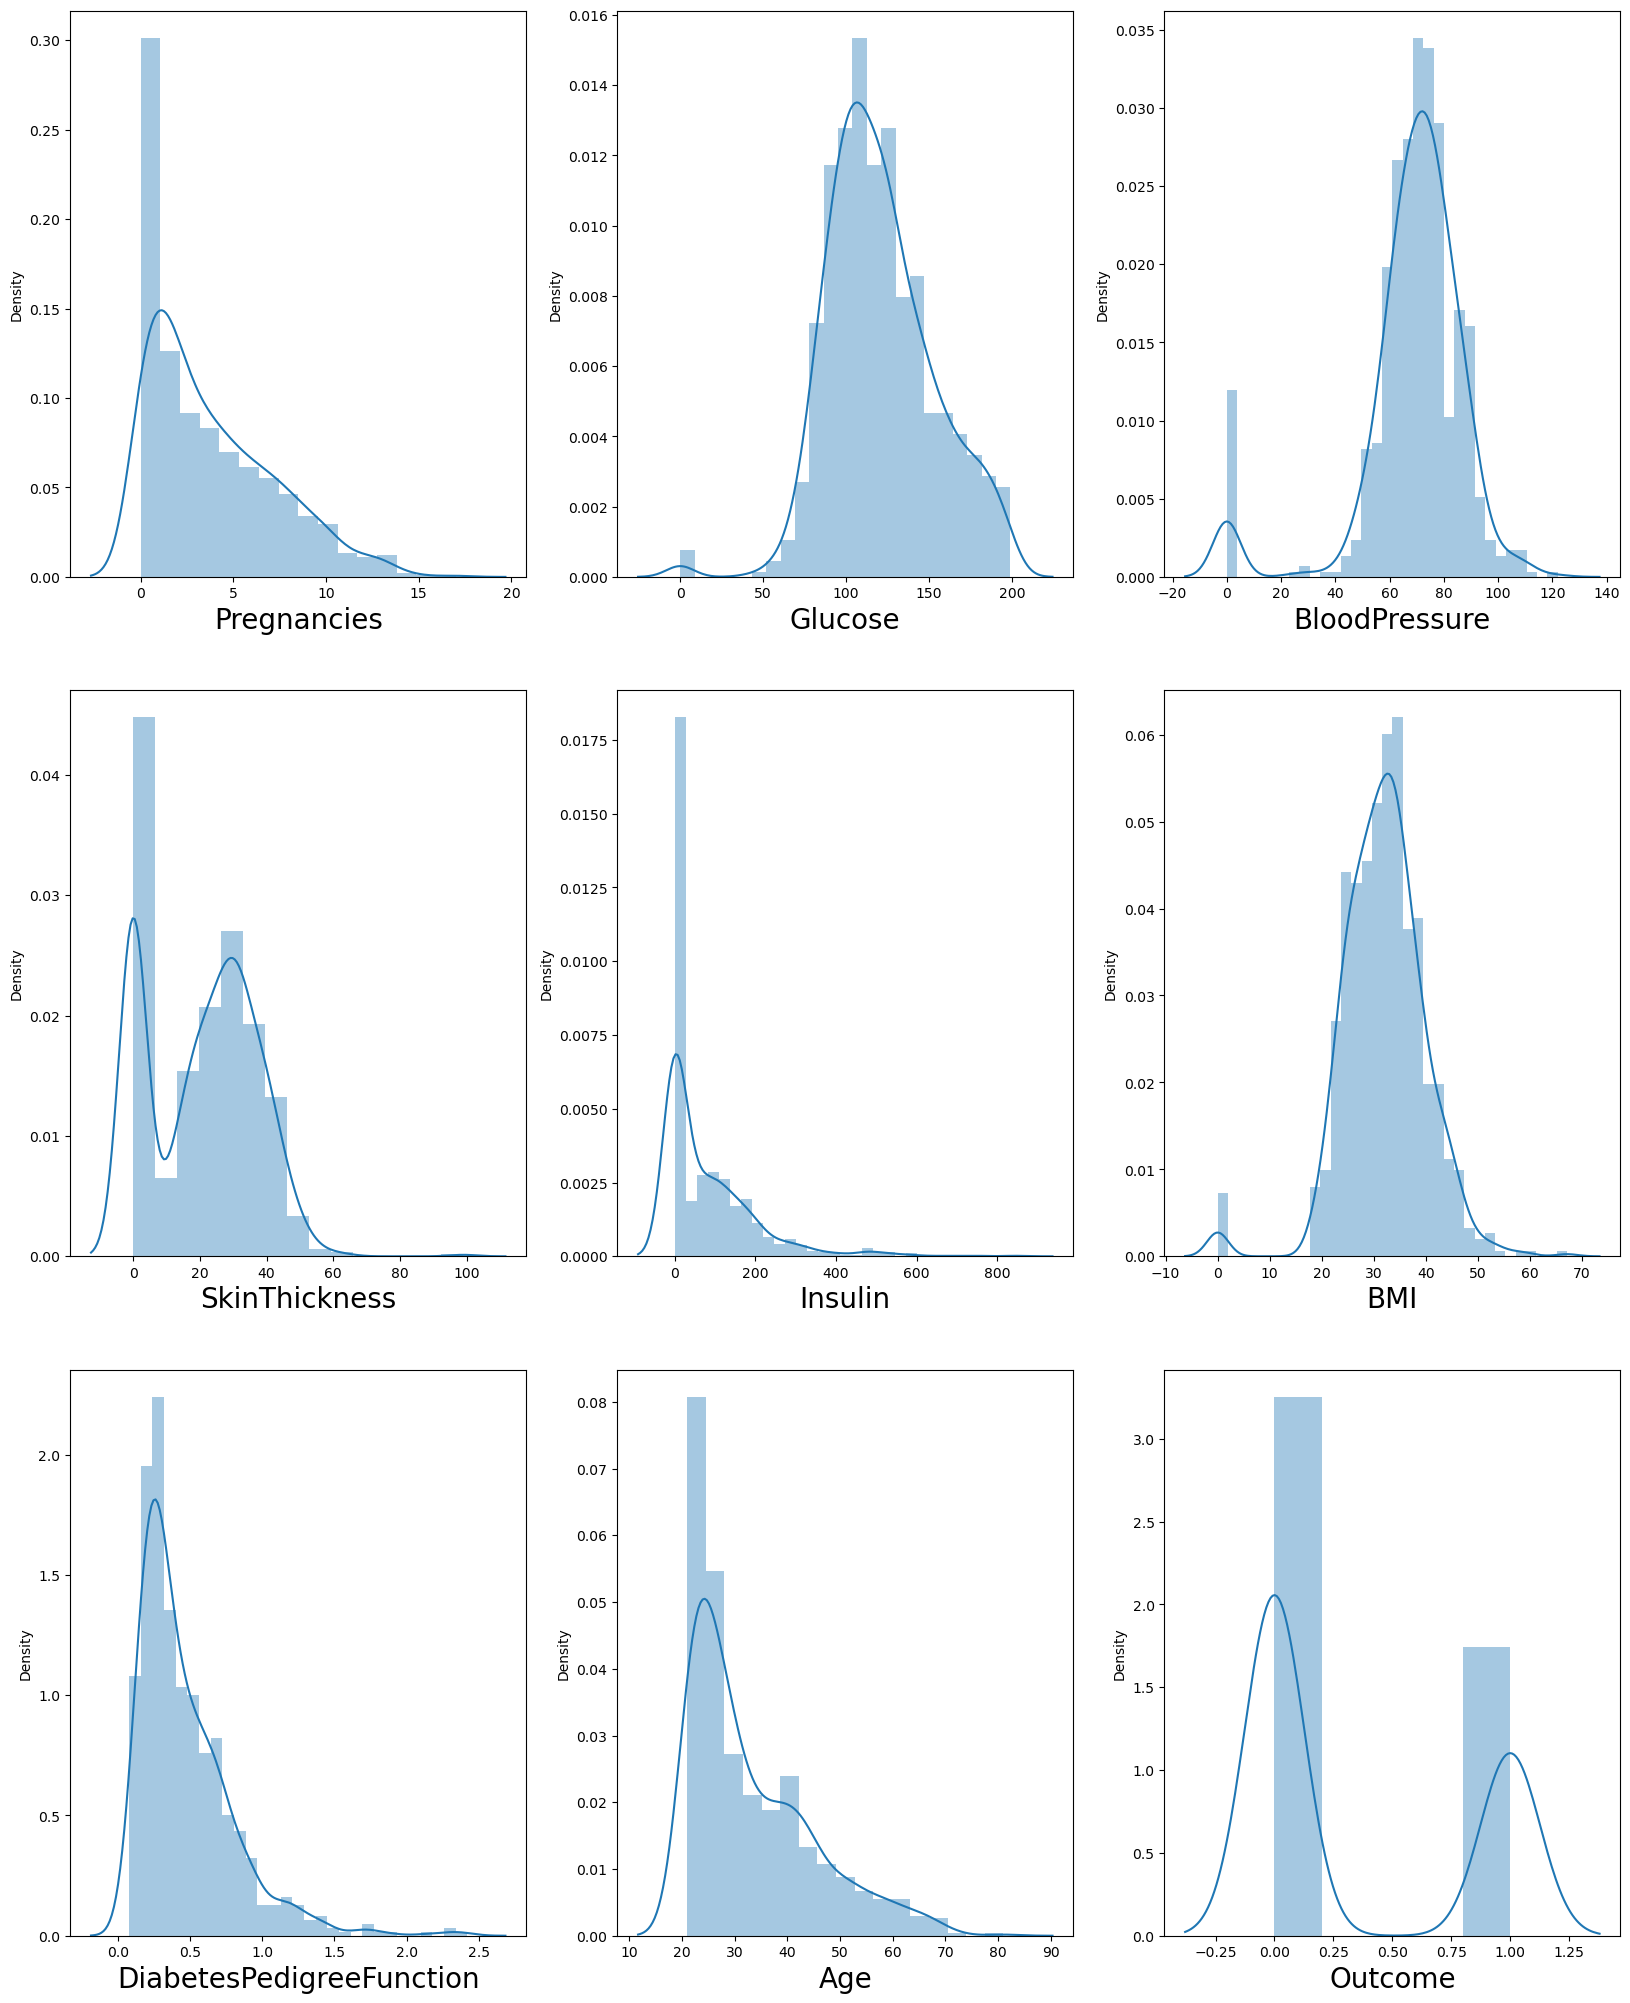

In [17]:
# let's see how data is distributed for every column
plt.figure(figsize=(20,25), facecolor='white')
plotnumber = 1

for column in data:
    if plotnumber<=9 :     # as there are 9 columns in the data
        ax = plt.subplot(3,3,plotnumber)
        sns.distplot(data[column])
        plt.xlabel(column,fontsize=20)
        #plt.ylabel('Salary',fontsize=20)
    plotnumber+=1
plt.show()

In [18]:
# replacing zero values with the mean of the column
data['BMI'] = data['BMI'].replace(0,data['BMI'].median())
data['BloodPressure'] = data['BloodPressure'].replace(0,data['BloodPressure'].median())
data['Insulin'] = data['Insulin'].replace(0,data['Insulin'].median())
data['SkinThickness'] = data['SkinThickness'].replace(0,data['SkinThickness'].median())

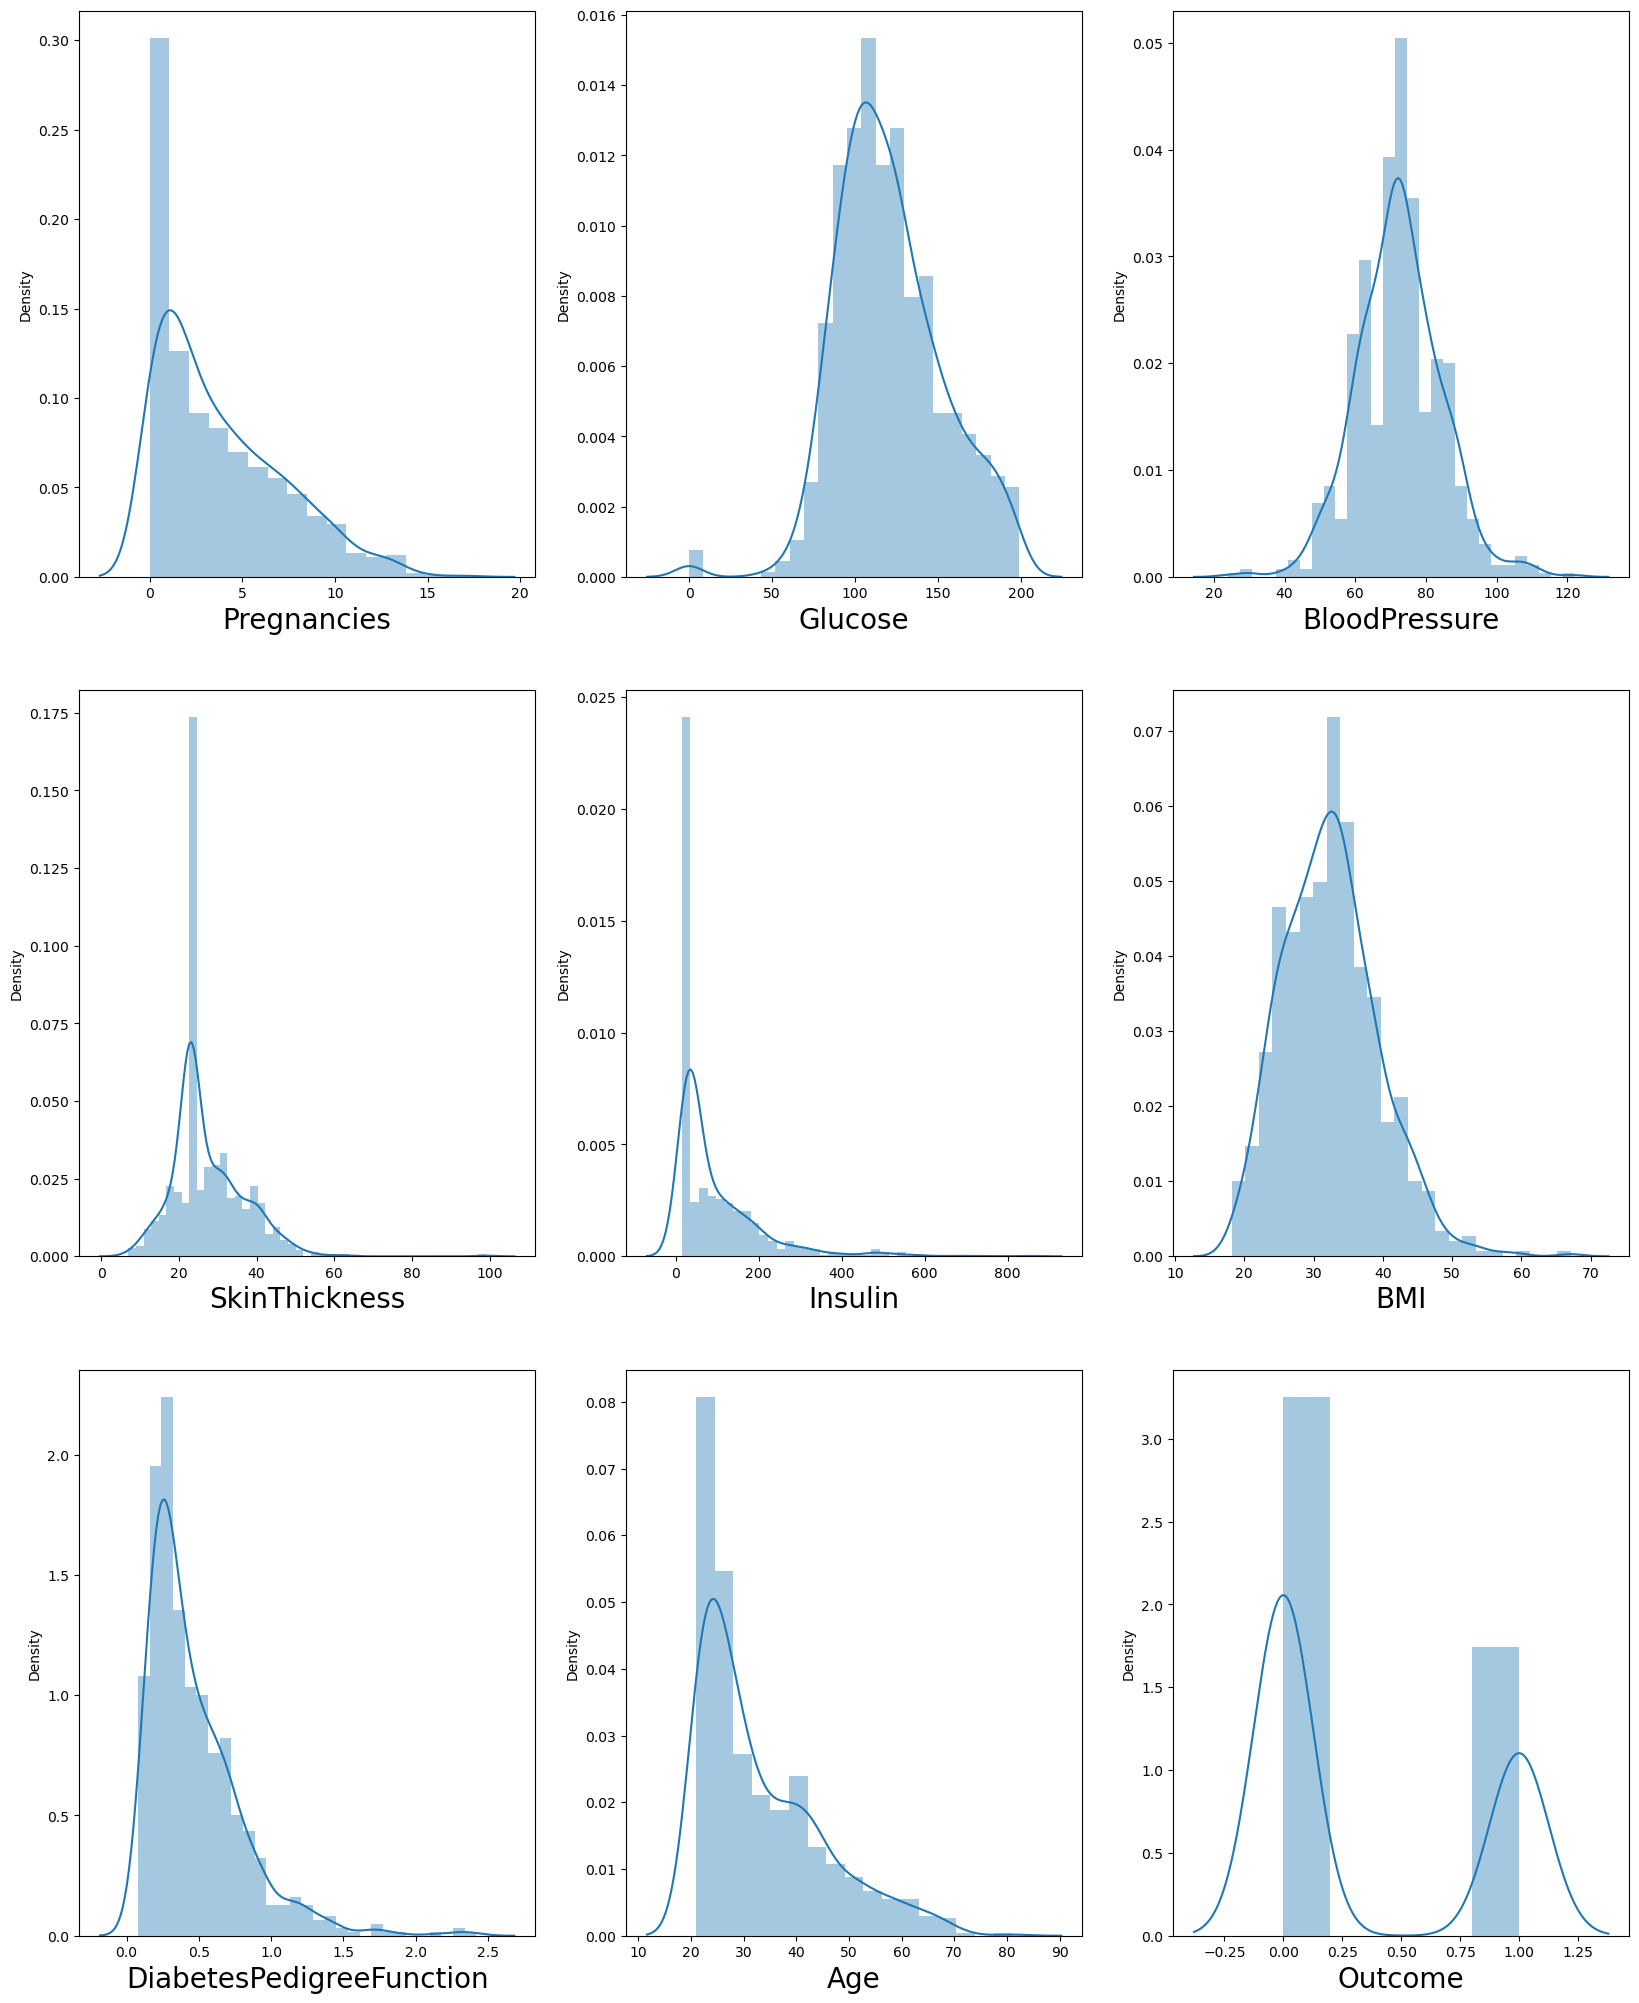

In [19]:
# let's see how data is distributed for every column
plt.figure(figsize=(20,25), facecolor='white')
plotnumber = 1

for column in data:
    if plotnumber<=9 :
        ax = plt.subplot(3,3,plotnumber)
        sns.distplot(data[column])
        plt.xlabel(column,fontsize=20)
        #plt.ylabel('Salary',fontsize=20)
    plotnumber+=1
plt.show()

# Model Creation

In [20]:
### Split X and Y
X = data.drop(columns = ['Outcome']) # Independent variables
y = data['Outcome'] # Dependent or target varaible.

In [21]:
## scaling the data
scalar = StandardScaler()
X_scaled = scalar.fit_transform(X)

In [22]:
## splitting the training and testing data
X_train,X_test,y_train,y_test=train_test_split(X_scaled,y,random_state=42)

In [23]:
## taking optimal k to determine how many nearest neighbors  to create

# create a list to store the error values for each k
error_rate = []

# Will take some time
for i in range(1,11):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train,y_train)
    pred_i = knn.predict(X_test)
    error_rate.append(np.mean(pred_i != y_test))

In [26]:
error_rate

[0.3697916666666667,
 0.3333333333333333,
 0.3333333333333333,
 0.3333333333333333,
 0.3072916666666667,
 0.328125,
 0.2760416666666667,
 0.2708333333333333,
 0.3072916666666667,
 0.265625]

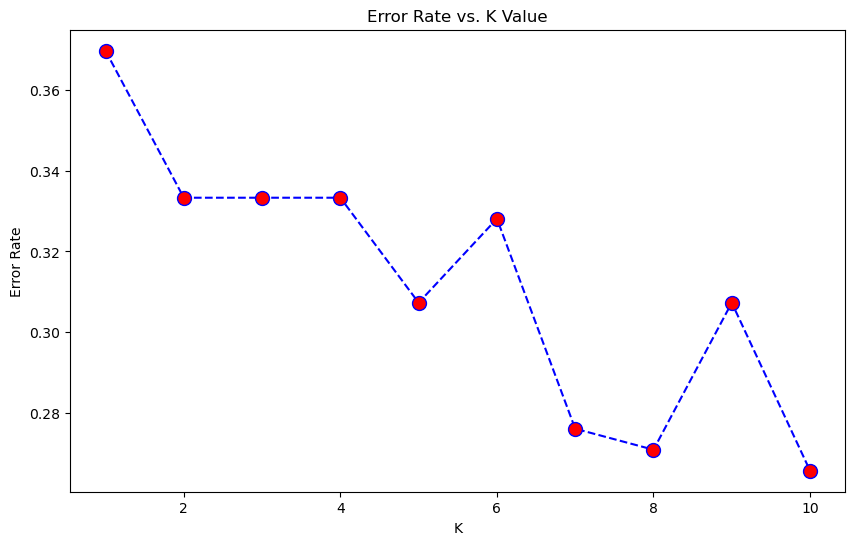

In [27]:
# Lets plot the k-value and error rate

plt.figure(figsize=(10,6))
plt.plot(range(1,11),error_rate,color='blue', linestyle='dashed', 
         marker='o',markerfacecolor='red', markersize=10)
plt.title('Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')
plt.show()

In [28]:
## This is reference code donot run this on current dataset.
## Error calculation for regression task
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

rmse_val = [] #create list to store rmse values for different k
for K in range(1,20):
    
    model = KNeighborsRegressor(n_neighbors = K)

    model.fit(X_train, y_train)  #fit the model
    pred=model.predict(X_test) #make prediction on test set
    error = np.sqrt(mean_squared_error(y_test,pred)) #calculate rmse
    rmse_val.append(error) #store rmse values
    print('RMSE value for k= ' , K , 'is:', error)

RMSE value for k=  1 is: 0.6081049799719344
RMSE value for k=  2 is: 0.48947250518628044
RMSE value for k=  3 is: 0.4756817719317697
RMSE value for k=  4 is: 0.46175333873544794
RMSE value for k=  5 is: 0.44884110031650776
RMSE value for k=  6 is: 0.44617717789469474
RMSE value for k=  7 is: 0.43886449026587526
RMSE value for k=  8 is: 0.4356359097151351
RMSE value for k=  9 is: 0.43286418098169627
RMSE value for k=  10 is: 0.42920711783473486
RMSE value for k=  11 is: 0.4283653823856992
RMSE value for k=  12 is: 0.42712567540782725
RMSE value for k=  13 is: 0.4247127466414957
RMSE value for k=  14 is: 0.424396830888294
RMSE value for k=  15 is: 0.418661889569349
RMSE value for k=  16 is: 0.4221160576735187
RMSE value for k=  17 is: 0.4213476963263697
RMSE value for k=  18 is: 0.4193394214851766
RMSE value for k=  19 is: 0.41966259036360687


In [29]:
# let's fit the data into KNN model and see how well it performs:
knn1 = KNeighborsClassifier(n_neighbors=5)
knn1.fit(X_train,y_train)

KNeighborsClassifier()

In [30]:
KNeighborsClassifier()

KNeighborsClassifier()

In [31]:
# Predict 
y_pred = knn1.predict(X_test)

In [32]:
# Checking Accuracy score
print("The accuracy score is : ", accuracy_score(y_test,y_pred))

The accuracy score is :  0.6927083333333334


In [33]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.76      0.76      0.76       123
           1       0.57      0.57      0.57        69

    accuracy                           0.69       192
   macro avg       0.67      0.66      0.67       192
weighted avg       0.69      0.69      0.69       192



In [34]:
recall1=recall_score(y_test,y_pred)
recall1

0.5652173913043478

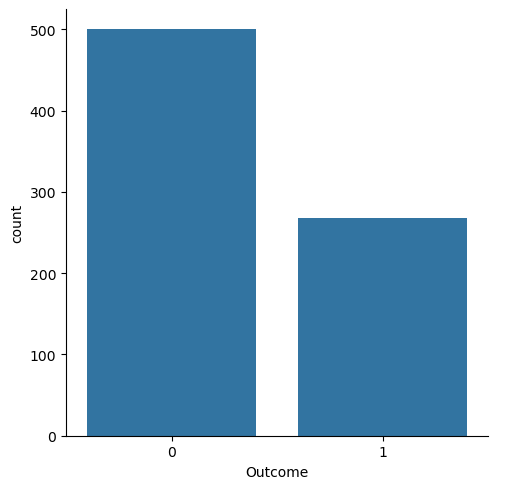

In [35]:
## checking the balance of traget
sns.catplot(x='Outcome',data=data,kind='count') # Imbalanced dataset

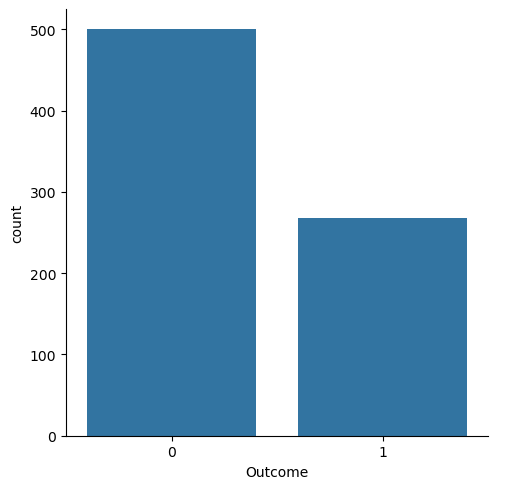

In [36]:
## checking the balance of traget
sns.catplot(x='Outcome',data=data,kind='count') # Imbalanced dataset

In [37]:
data.Outcome.value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [38]:
df=sns.load_dataset('iris')

In [39]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


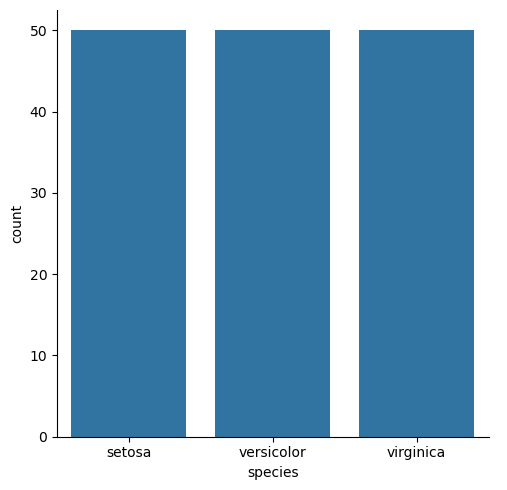

In [40]:
sns.catplot(x='species',data=df,kind='count') # Balanced dataset

In [41]:
df.species.value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

In [44]:
# Sampling 
# 1.over sampling incerse the minor value
# 2,under sampling
# imbalanced data then go through the this data

In [45]:
!pip install imblearn

  Attempting uninstall: joblib
    Found existing installation: joblib 1.1.1
    Uninstalling joblib-1.1.1:
      Successfully uninstalled joblib-1.1.1


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pandas-profiling 3.2.0 requires joblib~=1.1.0, but you have joblib 1.5.3 which is incompatible.
pandas-profiling 3.2.0 requires visions[type_image_path]==0.7.4, but you have visions 0.8.1 which is incompatible.


# SMOTE

In [46]:
# Apply SMOTE to balance the data
from imblearn.over_sampling import SMOTE
smote = SMOTE() ## object creation

In [47]:
y_train.value_counts()

Outcome
0    377
1    199
Name: count, dtype: int64

In [48]:
X_train_smote, y_train_smote = smote.fit_resample(X_train.astype('float'),
                                                  y_train)

In [49]:
y=np.array(y_train_smote)

In [50]:
y


array([1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0,
       0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1,
       1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1,
       0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0,
       0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0,

<Axes: ylabel='count'>

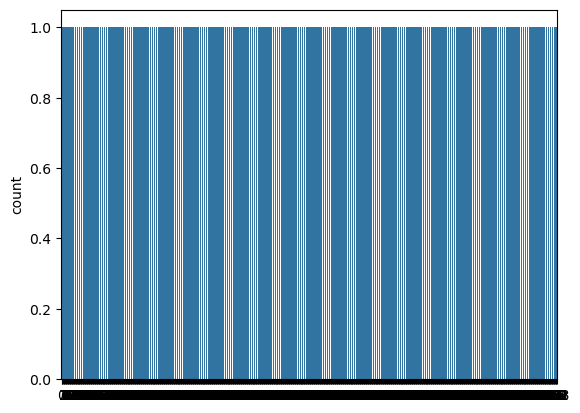

In [51]:
sns.countplot(y_train_smote)

<Axes: ylabel='count'>

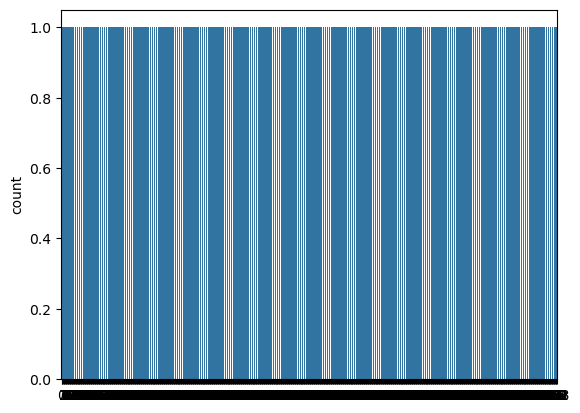

In [52]:
sns.countplot(y) 

In [53]:
from collections import Counter
print("Actual Classes",Counter(y_train))
print("SMOTE Classes",Counter(y_train_smote))

Actual Classes Counter({0: 377, 1: 199})
SMOTE Classes Counter({1: 377, 0: 377})


In [54]:

knn2 = KNeighborsClassifier(n_neighbors=5)
knn2.fit(X_train_smote, y_train_smote)

KNeighborsClassifier()

In [55]:
# Predict the output for X_tst
y_pred = knn2.predict(X_test)

In [56]:
print("The accuracy score is : ", accuracy_score(y_test,y_pred))

The accuracy score is :  0.6875


In [57]:

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.83      0.64      0.72       123
           1       0.55      0.77      0.64        69

    accuracy                           0.69       192
   macro avg       0.69      0.71      0.68       192
weighted avg       0.73      0.69      0.69       192



In [58]:
# apply knn categotical data only drop him

In [59]:
# using smote also